KNN - K-Nearest Neighbour

* Euclidean Distance :
{ (f11-f12)^2 + (f21-f22)^2 }^0.5

* diabetes.csv

In [1]:
import pandas as pd
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [6]:
from sklearn.neighbors import KNeighborsClassifier
nn=KNeighborsClassifier(n_neighbors=15)  # n_neighbour=K => K must be odd (bcz even can make tie)
model=nn.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

[1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 1 0 1 1 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 0 1 1 1 1 0
 1 0 1 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0
 0 0 0 1 0 0]


--- OR --- 

from sklearn.neighbors import KNeighborsClassifier
model=KNeighborsClassifier(n_neighbors=15) 
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)

In [8]:
diff=pd.DataFrame({'Actual':y_test,'Predicted':prediction})
diff

,Actual,Predicted
285,0,1
101,0,0
581,0,0
352,0,0
726,0,0
...,...,...
563,0,0
318,0,0
154,1,1
684,0,0


In [9]:
diff.to_excel('diabetes_data.xlsx')  # diff.to_csv('diabetes_data.csv')

In [10]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
print(cm)

[[89 10]
 [23 32]]


A  P
0  0   - 89  TN
0  1   - 10  FP
1  0   - 23  FN
1  1   - 32  TP

[ [TN FP]
  [FN TP]]

In [11]:
TN=cm[0][0]
FP=cm[0][1]
FN=cm[1][0]
TP=cm[1][1]
print(TN,FP,FN,TP)

89 10 23 32


* Accuracy Score = (TP+TN) / (TP+TN+FP+FN)

In [13]:
print('Accuracy Score: ', (TP+TN) / (TP+TN+FP+FN))

Accuracy Score:  0.7857142857142857


In [14]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:",accuracy_score(y_test,prediction))

Accuracy Score: 0.7857142857142857


* Error Rate = (FN+FP) / (total)
* or
* 1 - accuracy score

In [17]:
print("Error rate:",1-accuracy_score(y_test,prediction))

Error rate: 0.2142857142857143


* Sensitivity :

sensitivity = (TP)/(TP+FN)

In [18]:
print("Sensitivity score:", (TP)/(TP+FN)) # Positive cases accuracy

Sensitivity score: 0.5818181818181818


In [20]:
from sklearn.metrics import recall_score
print("Sensitivity:",recall_score(y_test,prediction))

Sensitivity: 0.5818181818181818


* Specificity :

Specificity = (TN)/(TN+FP)

In [19]:
print("Specificity :",(TN)/(TN+FP)) # Negative cases accuracy

Specificity : 0.898989898989899


In [21]:
from sklearn.metrics import recall_score
print("Specificity:",recall_score(y_test,prediction,pos_label=0))

Specificity: 0.898989898989899


* Precision Score :

* precision score = (TP)/(TP+FP)
* Positive prediction accuracy

In [22]:
from sklearn.metrics import precision_score
print("Precision score:",precision_score(y_test,prediction))

Precision score: 0.7619047619047619


In [40]:
# we can also use inbuilt method of accuracy
from sklearn.metrics import confusion_matrix
l=[]
for i in range(1,31,2):
    from sklearn.neighbors import KNeighborsClassifier
    nn=KNeighborsClassifier(n_neighbors=i)  
    model=nn.fit(x_train,y_train)
    prediction=model.predict(x_test)
    cm=confusion_matrix(y_test,prediction)
    TN=cm[0][0]
    FP=cm[0][1]
    FN=cm[1][0]
    TP=cm[1][1]
    accu=(TP+TN) / (TP+TN+FP+FN)
    l.append(accu)
    print('Accuracy Score: ', accu)
print('-'*40)
ind=l.index(max(l))
print("Highest Accuracy : ",max(l))
print("Index is:",end="")
print(2*ind1)

Accuracy Score:  0.7207792207792207
Accuracy Score:  0.7402597402597403
Accuracy Score:  0.7337662337662337
Accuracy Score:  0.7597402597402597
Accuracy Score:  0.7662337662337663
Accuracy Score:  0.7467532467532467
Accuracy Score:  0.7662337662337663
Accuracy Score:  0.7857142857142857
Accuracy Score:  0.7857142857142857
Accuracy Score:  0.7727272727272727
Accuracy Score:  0.7662337662337663
Accuracy Score:  0.7662337662337663
Accuracy Score:  0.7532467532467533
Accuracy Score:  0.7532467532467533
Accuracy Score:  0.7662337662337663
----------------------------------------
Highest Accuracy :  0.7857142857142857
Index is:15


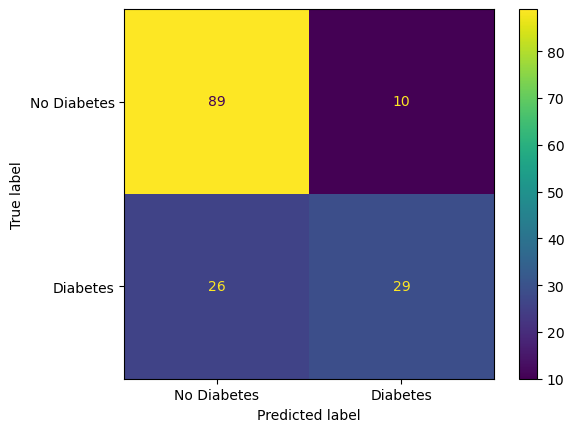

In [42]:
import matplotlib.pyplot as plt
from sklearn import metrics
cm_display=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,
                                         display_labels=['No Diabetes','Diabetes'])
cm_display.plot()
plt.show()